<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/flash_with_salt_water.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gas–oil–brine equilibrium and salt-water properties with NeqSim

This tutorial performs a three-phase TP flash for methane, n-heptane, water, and a neutral NaCl
pseudo-component. It connects phase equilibrium to brine density, viscosity, salting-out, and
operating-condition sensitivities.

## Learning objectives

After completing the notebook, you should be able to:

- convert a brine mass fraction into reproducible water and NaCl mole amounts;
- configure SRK-CPA and the `SALT_WATER` physical-property model;
- identify gas, oil, and aqueous phases after a TP flash;
- verify component and total-mass conservation independently;
- interpret salinity, temperature, and pressure trends; and
- recognize when a neutral-salt screening model is insufficient.

In [1]:
import importlib.metadata
import subprocess
import sys


subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--no-cache-dir",
        "--quiet",
        "neqsim",
    ],
    check=True,
    capture_output=True,
    text=True,
)

installed_neqsim_version = importlib.metadata.version("neqsim")
print(f"NeqSim {installed_neqsim_version} is ready.")

NeqSim 3.16.0 is ready.


In [2]:
import platform
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim


java_version_line = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [
            installed_neqsim_version,
            platform.python_version(),
            java_version_line,
        ],
    }
)
runtime_table

  Runtime                               Version
0  NeqSim                                3.16.0
1  Python                               3.12.13
2    Java  openjdk version "17.0.19" 2026-04-21

## Engineering context and model scope

Produced fluids often contain a hydrocarbon gas, a condensable oil fraction, and formation brine.
A TP flash determines the equilibrium phase split at specified temperature $T$ in K and absolute
pressure $P$ in bara. SRK-CPA is used because its association term represents water hydrogen
bonding, while NeqSim's `SALT_WATER` physical-property model supplies brine screening properties.

NaCl is represented here as a **neutral pseudo-component**. This is useful for phase partitioning
and preliminary density or viscosity studies, but it does not calculate ions, activity
coefficients, pH, mineral precipitation, corrosion, or scale risk. Those tasks require a qualified
electrolyte and solids workflow.

## Calculation basis and units

The base case contains 5 mol methane, 1 mol n-heptane, and 1.000 kg water. The brine salinity is
10 mass% NaCl on a total-brine basis. At 20°C and 50 bara, this synthetic basis produces distinct
gas, oil, and aqueous phases and avoids proprietary field-fluid data.

For water mass $m_w$, salt mass $m_s$, salt mass fraction $w_s$, and NaCl molar mass $M_s$,

$$
w_s = \frac{m_s}{m_s + m_w}
$$

and therefore

$$
n_s = \frac{w_s m_w}{(1-w_s)M_s}
$$

Masses use g, molar masses use g/mol, temperature uses °C at the notebook interface, and pressure
uses bara.

In [3]:
COMPONENTS = ["methane", "n-heptane", "water", "NaCl"]
MOLECULAR_WEIGHTS_G_PER_MOL = {
    "methane": 16.043,
    "n-heptane": 100.205,
    "water": 18.01528,
    "NaCl": 58.44277,
}

BASE_TEMPERATURE_C = 20.0
BASE_PRESSURE_BARA = 50.0
BASE_WATER_MASS_G = 1000.0
BASE_SALINITY_MASS_FRACTION = 0.10
BASE_METHANE_MOL = 5.0
BASE_HEPTANE_MOL = 1.0

basis_table = pd.DataFrame(
    {
        "Input": [
            "Temperature",
            "Pressure",
            "Methane",
            "n-Heptane",
            "Water mass",
            "NaCl mass fraction",
        ],
        "Value": [
            BASE_TEMPERATURE_C,
            BASE_PRESSURE_BARA,
            BASE_METHANE_MOL,
            BASE_HEPTANE_MOL,
            BASE_WATER_MASS_G,
            BASE_SALINITY_MASS_FRACTION,
        ],
        "Unit": ["°C", "bara", "mol", "mol", "g", "kg/kg brine"],
    }
)
basis_table

                Input   Value         Unit
0         Temperature    20.0           °C
1            Pressure    50.0         bara
2             Methane     5.0          mol
3           n-Heptane     1.0          mol
4          Water mass  1000.0            g
5  NaCl mass fraction     0.1  kg/kg brine

## Reusable flash function

Each case builds a fresh thermodynamic system, so sensitivity calculations do not inherit state
from an earlier flash. Mixing rule 10 is the recommended classic temperature-dependent CPA mixing
rule. Multiphase checking is enabled before the flash, and physical properties are initialized
only after equilibrium is found.

In [4]:
def brine_component_amounts(water_mass_g, salinity_mass_fraction):
    water_moles = water_mass_g / MOLECULAR_WEIGHTS_G_PER_MOL["water"]
    salt_mass_g = (
        salinity_mass_fraction
        / (1.0 - salinity_mass_fraction)
        * water_mass_g
    )
    salt_moles = salt_mass_g / MOLECULAR_WEIGHTS_G_PER_MOL["NaCl"]
    return water_moles, salt_moles, salt_mass_g


def run_brine_flash(
    temperature_c,
    pressure_bara,
    salinity_mass_fraction,
):
    water_moles, salt_moles, salt_mass_g = brine_component_amounts(
        BASE_WATER_MASS_G,
        salinity_mass_fraction,
    )
    feed_moles = {
        "methane": BASE_METHANE_MOL,
        "n-heptane": BASE_HEPTANE_MOL,
        "water": water_moles,
        "NaCl": salt_moles,
    }

    fluid = jneqsim.thermo.system.SystemSrkCPAstatoil(
        temperature_c + 273.15,
        pressure_bara,
    )
    for component_name in COMPONENTS:
        fluid.addComponent(component_name, feed_moles[component_name])

    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    fluid.setPhysicalPropertyModel(
        jneqsim.physicalproperties.system.PhysicalPropertyModel.SALT_WATER,
    )

    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.initProperties()

    return {
        "fluid": fluid,
        "feed_moles": feed_moles,
        "salt_mass_g": salt_mass_g,
        "salinity_mass_fraction": salinity_mass_fraction,
        "temperature_c": temperature_c,
        "pressure_bara": pressure_bara,
    }

## Base TP flash

The phase table reports equilibrium amount, density, and dynamic viscosity. Density uses kg/m³ and
viscosity uses cP, where 1 cP equals 0.001 kg/(m·s).

In [5]:
base_result = run_brine_flash(
    BASE_TEMPERATURE_C,
    BASE_PRESSURE_BARA,
    BASE_SALINITY_MASS_FRACTION,
)
base_fluid = base_result["fluid"]

phase_rows = []
for phase_index in range(base_fluid.getNumberOfPhases()):
    phase = base_fluid.getPhase(phase_index)
    phase_rows.append(
        {
            "Phase": str(phase.getPhaseTypeName()),
            "Amount [mol]": float(phase.getNumberOfMolesInPhase()),
            "Density [kg/m³]": float(phase.getDensity("kg/m3")),
            "Viscosity [cP]": float(phase.getViscosity("kg/msec")) * 1000.0,
        }
    )

phase_table = pd.DataFrame(phase_rows).set_index("Phase")
phase_table.round(6)

         Amount [mol]  Density [kg/m³]  Viscosity [cP]
Phase                                                 
gas          4.672296        36.676185        0.012098
oil          1.262480       645.113250        0.338132
aqueous     57.474854      1071.482450        1.201213

Three phases are present. Methane-rich gas is least dense, the hydrocarbon liquid is intermediate,
and the saline aqueous phase is densest. The phase labels are thermodynamic phase types rather
than equipment outlet names.

In [6]:
composition_rows = []
for phase_index in range(base_fluid.getNumberOfPhases()):
    phase = base_fluid.getPhase(phase_index)
    phase_name = str(phase.getPhaseTypeName())
    for component_name in COMPONENTS:
        phase_component = phase.getComponent(component_name)
        composition_rows.append(
            {
                "Phase": phase_name,
                "Component": component_name,
                "Mole fraction": float(phase_component.getx()),
                "Amount [mol]": float(
                    phase_component.getNumberOfMolesInPhase()
                ),
            }
        )

composition_table = pd.DataFrame(composition_rows)
composition_pivot = composition_table.pivot(
    index="Component",
    columns="Phase",
    values="Mole fraction",
)
composition_pivot.fillna(0.0).round(8)

Phase           aqueous       gas       oil
Component                                  
NaCl       3.307873e-02  0.000000  0.000000
methane    1.186200e-03  0.996242  0.219478
n-heptane  1.300000e-07  0.003206  0.780221
water      9.657349e-01  0.000552  0.000301

## Conservation checks

For every component $i$, the feed amount must equal the sum over phases $p$:

$$
n_{i,feed} = \sum_p n_{i,p}
$$

An independent mass balance converts the component amounts with fixed molecular weights:

$$
m = \sum_i n_i M_i
$$

These checks are essential because a converged flash is not, by itself, proof of a physically
usable result.

In [7]:
closure_rows = []
for component_name in COMPONENTS:
    feed_moles = base_result["feed_moles"][component_name]
    outlet_moles = 0.0
    for phase_index in range(base_fluid.getNumberOfPhases()):
        phase = base_fluid.getPhase(phase_index)
        outlet_moles += float(
            phase.getComponent(component_name).getNumberOfMolesInPhase()
        )

    closure_rows.append(
        {
            "Component": component_name,
            "Feed [mol]": feed_moles,
            "Phases [mol]": outlet_moles,
            "Residual [mol]": outlet_moles - feed_moles,
        }
    )

closure_table = pd.DataFrame(closure_rows).set_index("Component")
feed_mass_g = sum(
    base_result["feed_moles"][name] * MOLECULAR_WEIGHTS_G_PER_MOL[name]
    for name in COMPONENTS
)
outlet_mass_g = sum(
    row["Phases [mol]"] * MOLECULAR_WEIGHTS_G_PER_MOL[row["Component"]]
    for row in closure_rows
)
mass_residual_g = outlet_mass_g - feed_mass_g

display(closure_table.map(lambda value: f"{value:.12g}"))
print(f"Independent mass residual: {mass_residual_g:.3e} g")

              Feed [mol]    Phases [mol]      Residual [mol]
Component                                                   
methane                5               5   3.57136542561e-12
n-heptane              1  0.999999999997  -2.99660296577e-12
water      55.5084350618   55.5084350618  -5.47117906535e-13
NaCl       1.90119515401   1.90119515401  -1.90958360236e-14
Independent mass residual: -2.540e-10 g


The residuals are at floating-point round-off, confirming that methane, n-heptane, water, and the
neutral NaCl pseudo-component are conserved across the gas, oil, and aqueous phases.

## Salt location and base-case interpretation

The neutral salt representation should keep essentially all NaCl in the aqueous phase. Reporting
the phase-wise salt inventory makes that modeling assumption visible and testable.

In [8]:
salt_rows = []
for phase_index in range(base_fluid.getNumberOfPhases()):
    phase = base_fluid.getPhase(phase_index)
    salt_moles = float(
        phase.getComponent("NaCl").getNumberOfMolesInPhase()
    )
    salt_rows.append(
        {
            "Phase": str(phase.getPhaseTypeName()),
            "NaCl [mol]": salt_moles,
            "Feed recovery [%]": (
                100.0 * salt_moles / base_result["feed_moles"]["NaCl"]
            ),
        }
    )

salt_table = pd.DataFrame(salt_rows).set_index("Phase")
aqueous_salt_recovery = salt_table.loc["aqueous", "Feed recovery [%]"] / 100.0
base_aqueous = base_fluid.getPhase("aqueous")
base_gas = base_fluid.getPhase("gas")
base_oil = base_fluid.getPhase("oil")

display(salt_table.map(lambda value: f"{value:.10g}"))
print(f"Aqueous brine density: {base_aqueous.getDensity('kg/m3'):.6f} kg/m³")
print(f"Aqueous viscosity: {base_aqueous.getViscosity('kg/msec') * 1000.0:.6f} cP")

              NaCl [mol] Feed recovery [%]
Phase                                     
gas      4.672295747e-50   2.457557151e-48
oil      1.262480491e-50   6.640457127e-49
aqueous      1.901195154               100
Aqueous brine density: 1071.482450 kg/m³
Aqueous viscosity: 1.201213 cP


## Salinity sensitivity

The study varies NaCl from 0 to 20 mass% while holding water mass, hydrocarbons, temperature, and
pressure fixed. Higher salinity should increase brine density and reduce dissolved methane and
water carried by the gas. The latter two responses are useful qualitative salting-out checks.

In [9]:
salinity_values = [0.00, 0.05, 0.10, 0.15, 0.20]
salinity_rows = []

for salinity in salinity_values:
    case = run_brine_flash(
        BASE_TEMPERATURE_C,
        BASE_PRESSURE_BARA,
        salinity,
    )
    aqueous_phase = case["fluid"].getPhase("aqueous")
    gas_phase = case["fluid"].getPhase("gas")
    salinity_rows.append(
        {
            "NaCl [mass%]": 100.0 * salinity,
            "Brine density [kg/m³]": float(aqueous_phase.getDensity("kg/m3")),
            "Brine viscosity [cP]": (
                float(aqueous_phase.getViscosity("kg/msec")) * 1000.0
            ),
            "Aqueous methane x [mol/mol]": float(
                aqueous_phase.getComponent("methane").getx()
            ),
            "Gas water x [mol/mol]": float(
                gas_phase.getComponent("water").getx()
            ),
        }
    )

salinity_table = pd.DataFrame(salinity_rows)
salinity_table.round(8)

   NaCl [mass%]  ...  Gas water x [mol/mol]
0           0.0  ...               0.000571
1           5.0  ...               0.000562
2          10.0  ...               0.000552
3          15.0  ...               0.000541
4          20.0  ...               0.000530

[5 rows x 5 columns]

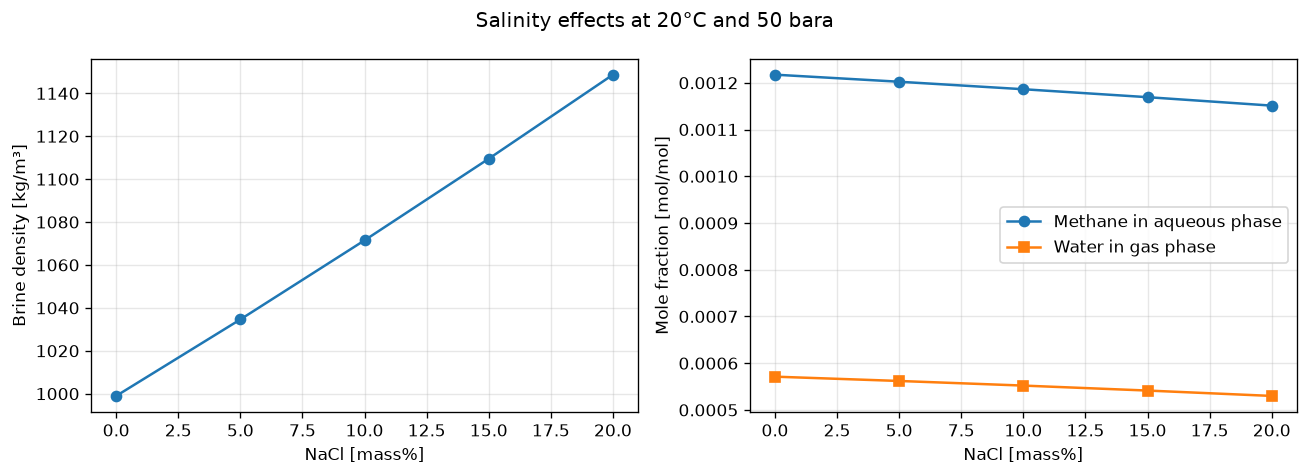

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    salinity_table["NaCl [mass%]"],
    salinity_table["Brine density [kg/m³]"],
    marker="o",
)
axes[0].set_xlabel("NaCl [mass%]")
axes[0].set_ylabel("Brine density [kg/m³]")
axes[0].grid(alpha=0.3)

axes[1].plot(
    salinity_table["NaCl [mass%]"],
    salinity_table["Aqueous methane x [mol/mol]"],
    marker="o",
    label="Methane in aqueous phase",
)
axes[1].plot(
    salinity_table["NaCl [mass%]"],
    salinity_table["Gas water x [mol/mol]"],
    marker="s",
    label="Water in gas phase",
)
axes[1].set_xlabel("NaCl [mass%]")
axes[1].set_ylabel("Mole fraction [mol/mol]")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.suptitle("Salinity effects at 20°C and 50 bara")
fig.tight_layout()
plt.show()

Brine density rises steadily with salinity. Both aqueous methane mole fraction and gas-phase water
content fall, which is the expected salting-out direction. The low-salinity viscosity point is not
used as a validation target because screening correlations can be non-smooth near their
composition limits.

## Temperature sensitivity

Temperature varies from 5°C to 60°C at 50 bara and 10 mass% NaCl. Warmer brine should become less
dense and less viscous, while its equilibrium water content in the gas should increase.

In [11]:
temperature_values_c = [5.0, 20.0, 40.0, 60.0]
temperature_rows = []

for temperature_c in temperature_values_c:
    case = run_brine_flash(
        temperature_c,
        BASE_PRESSURE_BARA,
        BASE_SALINITY_MASS_FRACTION,
    )
    aqueous_phase = case["fluid"].getPhase("aqueous")
    gas_phase = case["fluid"].getPhase("gas")
    temperature_rows.append(
        {
            "Temperature [°C]": temperature_c,
            "Brine density [kg/m³]": float(aqueous_phase.getDensity("kg/m3")),
            "Brine viscosity [cP]": (
                float(aqueous_phase.getViscosity("kg/msec")) * 1000.0
            ),
            "Gas water x [mol/mol]": float(
                gas_phase.getComponent("water").getx()
            ),
        }
    )

temperature_table = pd.DataFrame(temperature_rows)
temperature_table.round(8)

   Temperature [°C]  ...  Gas water x [mol/mol]
0               5.0  ...               0.000217
1              20.0  ...               0.000552
2              40.0  ...               0.001658
3              60.0  ...               0.004338

[4 rows x 4 columns]

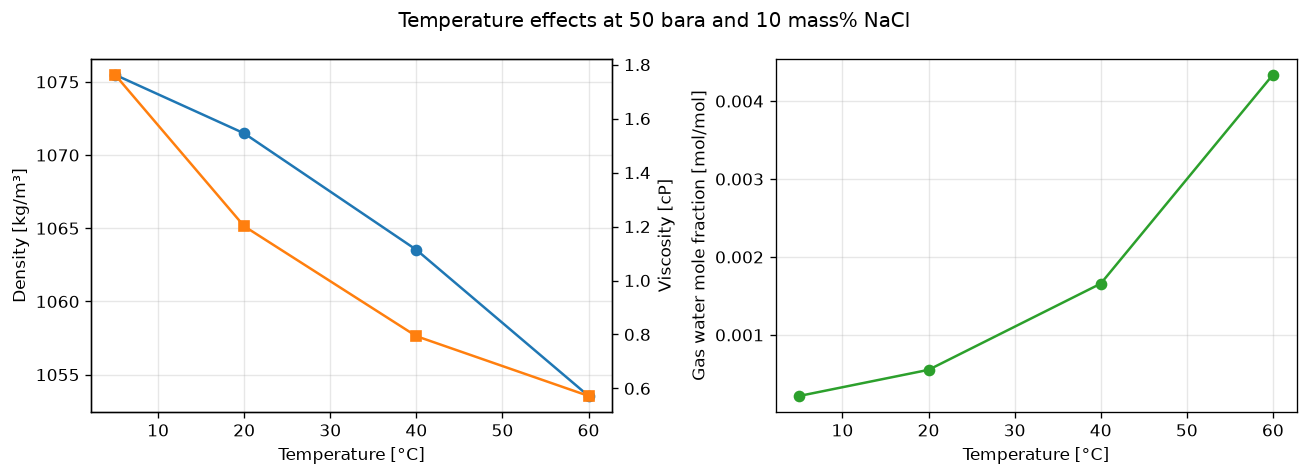

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    temperature_table["Temperature [°C]"],
    temperature_table["Brine density [kg/m³]"],
    marker="o",
    label="Density",
)
axes[0].set_xlabel("Temperature [°C]")
axes[0].set_ylabel("Density [kg/m³]")
axes[0].grid(alpha=0.3)

viscosity_axis = axes[0].twinx()
viscosity_axis.plot(
    temperature_table["Temperature [°C]"],
    temperature_table["Brine viscosity [cP]"],
    marker="s",
    color="tab:orange",
    label="Viscosity",
)
viscosity_axis.set_ylabel("Viscosity [cP]")

axes[1].plot(
    temperature_table["Temperature [°C]"],
    temperature_table["Gas water x [mol/mol]"],
    marker="o",
    color="tab:green",
)
axes[1].set_xlabel("Temperature [°C]")
axes[1].set_ylabel("Gas water mole fraction [mol/mol]")
axes[1].grid(alpha=0.3)

fig.suptitle("Temperature effects at 50 bara and 10 mass% NaCl")
fig.tight_layout()
plt.show()

## Pressure sensitivity

Pressure varies from 10 to 70 bara at 20°C and 10 mass% NaCl. Gas density and methane dissolution
should increase with pressure. Brine density is much less pressure-sensitive over this range.

In [13]:
pressure_values_bara = [10.0, 30.0, 50.0, 70.0]
pressure_rows = []

for pressure_bara in pressure_values_bara:
    case = run_brine_flash(
        BASE_TEMPERATURE_C,
        pressure_bara,
        BASE_SALINITY_MASS_FRACTION,
    )
    aqueous_phase = case["fluid"].getPhase("aqueous")
    gas_phase = case["fluid"].getPhase("gas")
    pressure_rows.append(
        {
            "Pressure [bara]": pressure_bara,
            "Brine density [kg/m³]": float(aqueous_phase.getDensity("kg/m3")),
            "Gas density [kg/m³]": float(gas_phase.getDensity("kg/m3")),
            "Aqueous methane x [mol/mol]": float(
                aqueous_phase.getComponent("methane").getx()
            ),
        }
    )

pressure_table = pd.DataFrame(pressure_rows)
pressure_table.round(8)

   Pressure [bara]  ...  Aqueous methane x [mol/mol]
0             10.0  ...                     0.000268
1             30.0  ...                     0.000757
2             50.0  ...                     0.001186
3             70.0  ...                     0.001561

[4 rows x 4 columns]

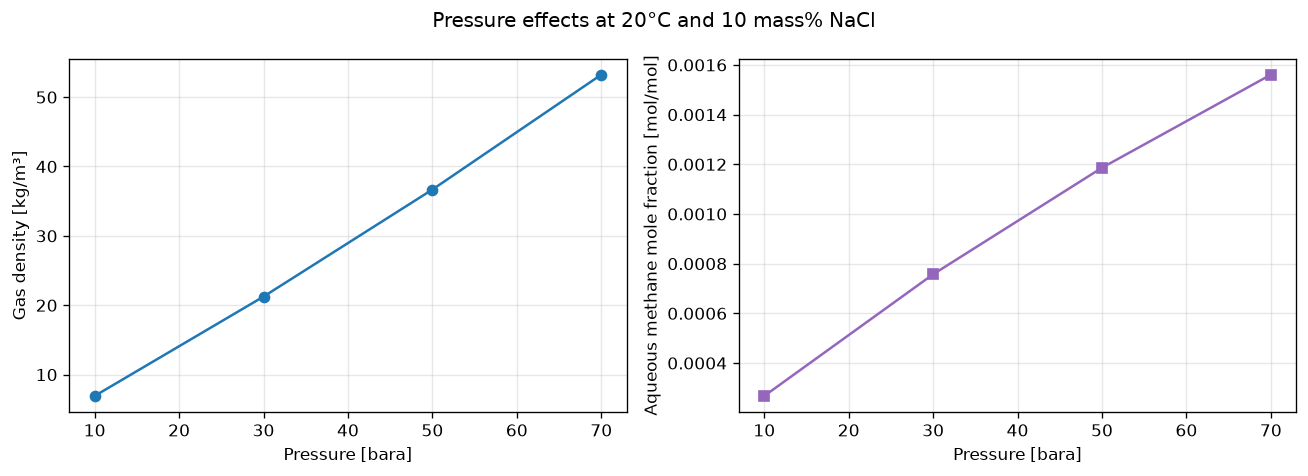

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    pressure_table["Pressure [bara]"],
    pressure_table["Gas density [kg/m³]"],
    marker="o",
)
axes[0].set_xlabel("Pressure [bara]")
axes[0].set_ylabel("Gas density [kg/m³]")
axes[0].grid(alpha=0.3)

axes[1].plot(
    pressure_table["Pressure [bara]"],
    pressure_table["Aqueous methane x [mol/mol]"],
    marker="s",
    color="tab:purple",
)
axes[1].set_xlabel("Pressure [bara]")
axes[1].set_ylabel("Aqueous methane mole fraction [mol/mol]")
axes[1].grid(alpha=0.3)

fig.suptitle("Pressure effects at 20°C and 10 mass% NaCl")
fig.tight_layout()
plt.show()

## Engineering validation

The assertions below combine numerical, conservation, phase-behavior, property-bound, and trend
checks. They are intentionally focused on this tutorial basis rather than being universal design
limits.

In [15]:
component_residuals = closure_table["Residual [mol]"].to_numpy(dtype=float)
salinity_density = salinity_table["Brine density [kg/m³]"].to_numpy()
salinity_methane = salinity_table["Aqueous methane x [mol/mol]"].to_numpy()
salinity_gas_water = salinity_table["Gas water x [mol/mol]"].to_numpy()
temperature_density = temperature_table["Brine density [kg/m³]"].to_numpy()
temperature_viscosity = temperature_table["Brine viscosity [cP]"].to_numpy()
temperature_gas_water = temperature_table["Gas water x [mol/mol]"].to_numpy()
pressure_gas_density = pressure_table["Gas density [kg/m³]"].to_numpy()
pressure_methane = pressure_table["Aqueous methane x [mol/mol]"].to_numpy()

base_phase_names = set(phase_table.index)
non_aqueous_salt_moles = salt_table.loc[["gas", "oil"], "NaCl [mol]"].sum()
base_gas_methane_x = float(base_gas.getComponent("methane").getx())
base_oil_heptane_x = float(base_oil.getComponent("n-heptane").getx())
base_aqueous_water_x = float(base_aqueous.getComponent("water").getx())

checks = [
    ("three phases", base_fluid.getNumberOfPhases() == 3),
    ("phase labels", base_phase_names == {"gas", "oil", "aqueous"}),
    ("finite phase table", np.isfinite(phase_table.to_numpy()).all()),
    ("positive phase amounts", (phase_table["Amount [mol]"] > 0.0).all()),
    ("gas density bound", 5.0 < phase_table.loc["gas", "Density [kg/m³]"] < 150.0),
    ("oil density bound", 500.0 < phase_table.loc["oil", "Density [kg/m³]"] < 900.0),
    ("brine density bound", 1000.0 < phase_table.loc["aqueous", "Density [kg/m³]"] < 1300.0),
    (
        "density ordering",
        phase_table["Density [kg/m³]"].sort_values().index.tolist()
        == ["gas", "oil", "aqueous"],
    ),
    ("positive viscosities", (phase_table["Viscosity [cP]"] > 0.0).all()),
    ("component closure", np.max(np.abs(component_residuals)) < 1.0e-8),
    ("mass closure", abs(mass_residual_g) < 1.0e-6),
    ("aqueous salt recovery", aqueous_salt_recovery > 0.999999999),
    ("non-aqueous salt exclusion", non_aqueous_salt_moles < 1.0e-12),
    ("methane-rich gas", base_gas_methane_x > 0.8),
    ("heptane-rich oil", base_oil_heptane_x > 0.7),
    ("water-rich aqueous phase", base_aqueous_water_x > 0.9),
    ("salinity density trend", np.all(np.diff(salinity_density) > 0.0)),
    ("salting-out methane trend", np.all(np.diff(salinity_methane) < 0.0)),
    ("salting-out water trend", np.all(np.diff(salinity_gas_water) < 0.0)),
    ("temperature density trend", np.all(np.diff(temperature_density) < 0.0)),
    ("temperature viscosity trend", np.all(np.diff(temperature_viscosity) < 0.0)),
    ("temperature water trend", np.all(np.diff(temperature_gas_water) > 0.0)),
    ("pressure gas-density trend", np.all(np.diff(pressure_gas_density) > 0.0)),
    ("pressure methane-solubility trend", np.all(np.diff(pressure_methane) > 0.0)),
    ("base salinity exact", abs(base_result["salinity_mass_fraction"] - 0.10) < 1.0e-12),
    ("finite salinity study", np.isfinite(salinity_table.to_numpy()).all()),
    ("finite temperature study", np.isfinite(temperature_table.to_numpy()).all()),
    ("finite pressure study", np.isfinite(pressure_table.to_numpy()).all()),
]

failed_checks = [name for name, passed in checks if not passed]
assert not failed_checks, f"Failed engineering checks: {failed_checks}"
print(f"All {len(checks)} engineering checks passed.")

All 28 engineering checks passed.


## Limitations and applicability

- This is an educational equilibrium screen, not a separator or produced-water design guarantee.
- The neutral NaCl pseudo-component does not calculate ionic speciation, pH, ion activities,
  electrochemical corrosion, hydrate inhibition, or mineral saturation.
- The `SALT_WATER` density and viscosity correlations should be checked against laboratory brine
  data at the actual ion composition, temperature, and pressure before design use.
- The synthetic methane/n-heptane basis is deliberately compact. Real fluids need compositional
  characterization, heavy-end treatment, and validated binary parameters.
- Equilibrium predicts final phase allocation, not mass-transfer rate, residence time, entrainment,
  emulsions, or separator hydraulics.

## References and next steps

- [NeqSim thermodynamic-model guidance](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [SRK-CPA system source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/thermo/system/SystemSrkCPAstatoil.java)
- [`PhysicalPropertyModel` source and `SALT_WATER` option](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/physicalproperties/system/PhysicalPropertyModel.java)
- [NeqSim on PyPI](https://pypi.org/project/neqsim/)

Practical exercises:

1. Replace the synthetic hydrocarbon feed with a characterized gas-condensate composition.
2. Compare the neutral-salt screen with a separately qualified electrolyte-CPA calculation using
   explicit ions, then check both against measured methane solubility.
3. Add CaCl₂ and NaHCO₃ only after selecting an electrolyte model and defining a charge-balanced
   analytical brine composition.
4. Pass each equilibrium phase to a downstream separator, pump, or compressor model and preserve
   the component-balance checks.